In [10]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

In [11]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

#Si hay lectura correcta
if img is not None:
    #Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print('Imagen leída correctamente')
else: 
    print('Imagen no encontrada')
    
#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(ggris, 100, 150)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)

Imagen leída correctamente


maxfil = 0.3711
Umbral = 0.3340
Número de filas que cumplen la condición: 9
Filas: [  3   5   6   8  15  20  24  91 100]


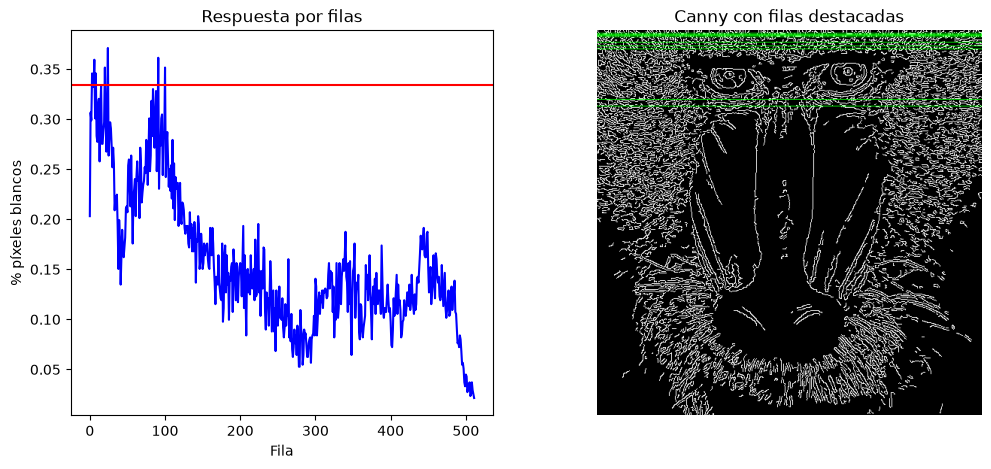

In [12]:
# El contenido de la imagen resultado de Canny son valores 0 o 255
# Cuenta los píxeles blancos por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normaliza: % de píxeles blancos por fila
# 255 * ancho = máximo posible de blancos en cada fila
rows = row_counts[:, 0] / (255 * canny.shape[1])

# Valor máximo de píxeles blancos por fila
maxfil = np.max(rows)

# Umbral: 90% del máximo
umbral = 0.90 * maxfil

# Filas que cumplen la condición
filas_ok = np.where(rows >= umbral)[0]

print(f"maxfil = {maxfil:.4f}")
print(f"Umbral = {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(filas_ok)}")
print(f"Filas: {filas_ok}")

# Para resaltar en la imagen de Canny, dibujamos una línea horizontal
# en cada fila que cumple la condición
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

for f in filas_ok:
    cv2.line(canny_color, (0, f), (canny.shape[1] - 1, f), (0, 255, 0), 1)

# También podemos mostrar la curva de respuesta por filas y marcar el umbral
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rows, color='blue')
plt.axhline(umbral, color='red') 
plt.title("Respuesta por filas")
plt.xlabel("Fila")
plt.ylabel("% píxeles blancos")

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny con filas destacadas")
plt.imshow(canny_color)

plt.show()

**TAREA:** Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

RESULTADOS DE SOBEL UMBRALIZADO
--------------------------------
Umbral aplicado: 90

Filas:
Máximo de píxeles blancos, max_rows: 0.466796875
90% de max_rows: 0.4201171875
Número de filas seleccionadas: 23
Posiciones de las filas: [  1   2   3   4   5   6   7   8  11  12  19  20  24  26  51  80  81  82
  83  84  85  87 100]

Columnas:
Máximo de píxeles blancos, max_cols: 0.470703125
90% de max_cols: 0.4236328125
Número de columnas seleccionadas: 5
Posiciones de las columnas: [104 105 127 287 288]


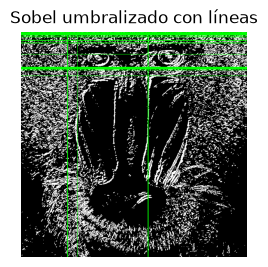

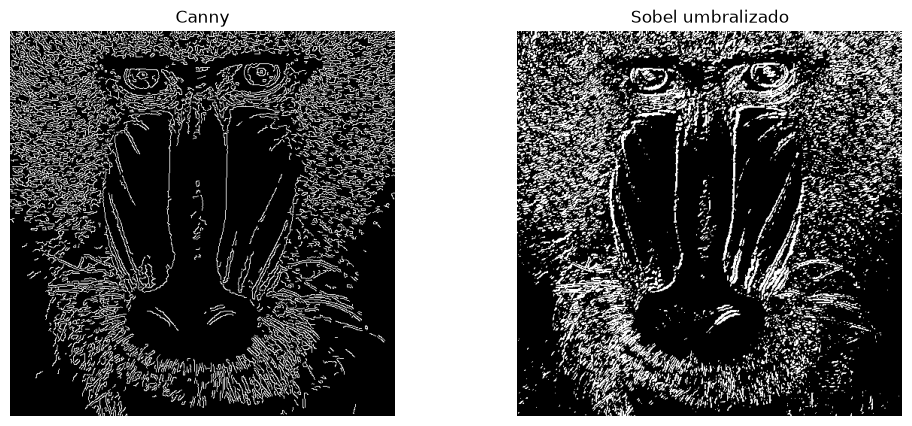

In [13]:
#Define valor umbral
valorUmbralSobel8 = 90
#Obtiene imagen umbralizada para dicho valor definido
_, sobel8Umbralizada = cv2.threshold(sobel8, valorUmbralSobel8, 255, cv2.THRESH_BINARY)

#Cuenta el número de píxeles blancos (255) por fila y por columna
#Suma los valores de los pixeles por fila y por columna
row_counts = cv2.reduce(sobel8Umbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(sobel8Umbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
rows = row_counts[:, 0] / (255 * sobel8Umbralizada.shape[1])
#De la misma manera con las columnas
cols = col_counts[0] / (255 * sobel8Umbralizada.shape[0])

#Calcula el máximo de filas y columnas
max_rows = np.max(rows)
max_cols = np.max(cols)

#Se determina aquellas filas y columnas que superan el 0.9 del máximo
threshold_rows = 0.9 * max_rows
threshold_cols = 0.9 * max_cols

#Posiciones que cumplen la condición de superar el 0.9 del máximo
rows_above_threshold = np.where(rows > threshold_rows)[0]
cols_above_threshold = np.where(cols > threshold_cols)[0]

#Remarque de las filas y columnas que superan el 0.9 del máximo en la imagen umbralizada de Sobel
sobel8_color = cv2.cvtColor(sobel8Umbralizada, cv2.COLOR_GRAY2BGR)

for r in rows_above_threshold:
    cv2.line(sobel8_color, (0, r), (sobel8_color.shape[1], r), (0, 255, 0), 1)

for c in cols_above_threshold:
    cv2.line(sobel8_color, (c, 0), (c, sobel8_color.shape[0]), (0, 255, 0), 1)
    
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Sobel umbralizado con líneas")
plt.imshow(sobel8_color)

#Resultados númericos
print("RESULTADOS DE SOBEL UMBRALIZADO")
print("--------------------------------")
print("Umbral aplicado:", valorUmbralSobel8)

print("\nFilas:")
print("Máximo de píxeles blancos, max_rows:", max_rows)
print("90% de max_rows:", threshold_rows)
print("Número de filas seleccionadas:", len(rows_above_threshold))
print("Posiciones de las filas:", rows_above_threshold)

print("\nColumnas:")
print("Máximo de píxeles blancos, max_cols:", max_cols)
print("90% de max_cols:", threshold_cols)
print("Número de columnas seleccionadas:", len(cols_above_threshold))
print("Posiciones de las columnas:", cols_above_threshold)

#Comparación de resultados de Canny y Sobel umbralizado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel8Umbralizada, cmap="gray")
plt.title("Sobel umbralizado")
plt.axis("off")

plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [9]:

vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)

while True:
    ret, frame = vid.read()
    if not ret: 
        break

    framem = cv2.flip(frame, 1)

    hsv = cv2.cvtColor(framem, cv2.COLOR_BGR2HSV)

    bajo_piel = np.array([0, 20, 70], dtype=np.uint8)
    alto_piel = np.array([20, 255, 255], dtype=np.uint8)

    mascara = cv2.inRange(hsv, bajo_piel, alto_piel)

    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        
        if area > 4000:
            x, y, w, h = cv2.boundingRect(contorno)


            roi = framem[y:y+h, x:x+w]
            
            roi_censurada = cv2.GaussianBlur(roi, (99, 99), 30)
            
            framem[y:y+h, x:x+w] = roi_censurada
            
            cv2.rectangle(framem, (x, y), (x+w, y+h), (200, 200, 200), 2)

    cv2.imshow('Censura por Color de Piel', framem)
    cv2.imshow('Mascara Interna (Depuracion)', mascara)

    # Salir con ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()